<center><strong><span style="font-family:Georgia, serif;font-size: 26px;">Barrier Call Option Pricing via Fokker-Planck Equation</span></strong></center>
<center><em>Using the Heston Stochastic Volatility Model &amp; B-Spline Variational Approach</em></center>

# Introduction

This notebook demonstrates the **FPE Engine** — a high-performance Mojo-backed solver for the Fokker-Planck equation under the Heston stochastic volatility model.

Applying the variational approach leads to the weak formulation of the Fokker-Planck equation (FPE). By replacing the probability density function (PDF) with an approximation based on a combination of B-spline basis functions in the weak formulation, we obtain a system of ordinary differential equations (ODEs). This system is solved numerically using a fifth-order implicit Runge-Kutta method (Radau IIA). Finally, the numerical solution is applied to price barrier options under the Heston stochastic volatility model.

Paper Source: Stoykov, S. (2024). [Numerical Solution of Fokker-Planck Equation by Variational Approach — an Application to Pricing Barrier Options. *Wilmott*, 2024(133).](https://doi.org/10.54946/wilm.12077)

## Heston Model

$$\begin{aligned}
dS_t &= rS_t\,dt + \sqrt{V_t}\,S_t\,dW_t^S \\
dV_t &= \kappa(\theta - V_t)\,dt + \eta\sqrt{V_t}\,dW_t^V
\end{aligned}$$

where $S_t$ is the asset price, $V_t$ is the variance, $r$ is the risk-free rate, $\theta$ is the long-term variance, $\kappa$ is the mean-reversion rate, $\eta$ is the volatility of variance, and $W_t^S$, $W_t^V$ are Wiener processes with correlation $\rho$.

## Fokker-Planck Equation

$$\begin{aligned}
\frac{\partial p}{\partial t} + r\frac{\partial}{\partial s}(sp) + \frac{\partial}{\partial v}[\kappa(\theta - v)p]
- \frac{1}{2}\frac{\partial^2}{\partial s^2}(s^2 vp) \\
- \rho\eta\frac{\partial^2}{\partial s\partial v}(svp) - \frac{1}{2}\eta^2\frac{\partial^2}{\partial v^2}(vp) = 0
\end{aligned}$$

The **variational formulation** seeks an approximation:

$$p(s,v,t) = \sum_{i=1}^{k} \varphi_i(s,v)\,q_i(t)$$

where $\varphi_i(s,v)$ are tensor-product B-spline shape functions and $q_i(t)$ are time-dependent coefficients, leading to the ODE system:

$$\mathbf{M}\dot{\mathbf{q}}(t) + \mathbf{K}\mathbf{q}(t) = \mathbf{0}$$

solved with the Radau IIA implicit Runge-Kutta method.

## Numerical Procedure

1. **Discretization**: Non-uniform B-spline knot vectors concentrate points near the initial condition $(S_0, V_0)$
2. **Initial Condition**: A narrow normal distribution approximating the delta function at $(S_0, V_0)$
3. **ODE Solving**: Radau IIA (5th-order implicit Runge-Kutta) for stiff systems
4. **Pricing**: Integrate payoff against the terminal PDF

In [1]:
import numpy as np
import polars as pl
from scipy import sparse
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from mpl_toolkits.mplot3d import Axes3D
from fpe_engine import Compute, price, PriceResult

plt.style.use('ggplot')

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

In [2]:
def surface_3d_mpl(s_grid, v_grid, Z, title="", s_label="s", v_label="v",
                    figsize=(10, 7), cmap="turbo", elev=25, azim=-60):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    S, V = np.meshgrid(s_grid, v_grid, indexing="ij")
    surf = ax.plot_surface(S, V, Z, cmap=cmap, linewidth=0,
                           antialiased=True, alpha=0.95)
    ax.set_xlabel(s_label)
    ax.set_ylabel(v_label)
    ax.set_zlabel("Density")
    ax.set_title(title, pad=20)
    ax.view_init(elev=elev, azim=azim)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=20, pad=0.1)
    fig.tight_layout()
    return fig, ax


def melt_2d(arr, s_grid, v_grid, name="density"):
    n_s, n_v = arr.shape
    vv, ss = np.meshgrid(v_grid, s_grid, indexing="ij")
    return pl.DataFrame({"s": ss.ravel(), "v": vv.ravel(), name: arr.ravel()})

---
# 1. Quick Start

The fastest way to get a price — just two lines:

In [3]:
result = price(S0=60.0, V0=0.1, T=0.6, r=0.1, n_s=16, n_v=16, K=100.0)
print(f"European call price at K=100: {result.prices[0]:.6f}")
print(f"Delta: {result.deltas[0]:.6f}")
print(f"Gamma: {result.gammas[0]:.6f}")
print(f"Vega: {result.vegas[0]:.6f}")

European call price at K=100: 0.199286
Delta: 0.017885
Gamma: 0.003026
Vega: -0.443417


---
# 2. Parameters & Setup

| Parameter | Value | Description |
|-----------|-------|-------------|
| S0 | 60.0 | Initial asset price |
| V0 | 0.1 | Initial variance |
| r | 0.1 | Risk-free rate |
| T | 0.6 | Time to maturity |
| kappa | 1.2 | Mean-reversion speed |
| theta | 0.05 | Long-term variance |
| sigma (eta) | 0.35 | Vol of variance |
| rho | -0.4 | Correlation |
| Barrier | 50.0 | Knock-out level (barrier only) |

We create two pricers — one for a **European call** and one for a **down-and-out barrier call** (barrier=50).

In [4]:
HESTON = dict(kappa=1.2, theta=0.05, sigma=0.35, rho=-0.4, r=0.1, T=0.6, S0=60.0, V0=0.1)

pricer_eu = Compute(**HESTON, n_s=38, n_v=38, option_type="european_call", barrier=0.0)
pricer_bar = Compute(**HESTON, n_s=38, n_v=38, option_type="down_and_out_call", barrier=50.0)

print("Pricers created.")

Pricers created.


---
# 3. Knot Points

Non-uniform knot vectors concentrate points near the initial condition $(S_0, V_0)$ for better resolution where the PDF is largest. The barrier pricer also adjusts the domain to account for the barrier level.

In [5]:
knots_eu = pricer_eu.knots
knots_bar = pricer_bar.knots

df_knots = pl.concat([
    pl.DataFrame({"s": knots_eu.s, "type": "European"}),
    pl.DataFrame({"s": knots_bar.s, "type": "Barrier"}),
])

df_knots_v = pl.concat([
    pl.DataFrame({"v": knots_eu.v, "type": "European"}),
    pl.DataFrame({"v": knots_bar.v, "type": "Barrier"}),
])

grid_df = (
    df_knots
    .join(df_knots_v, how="cross")
)

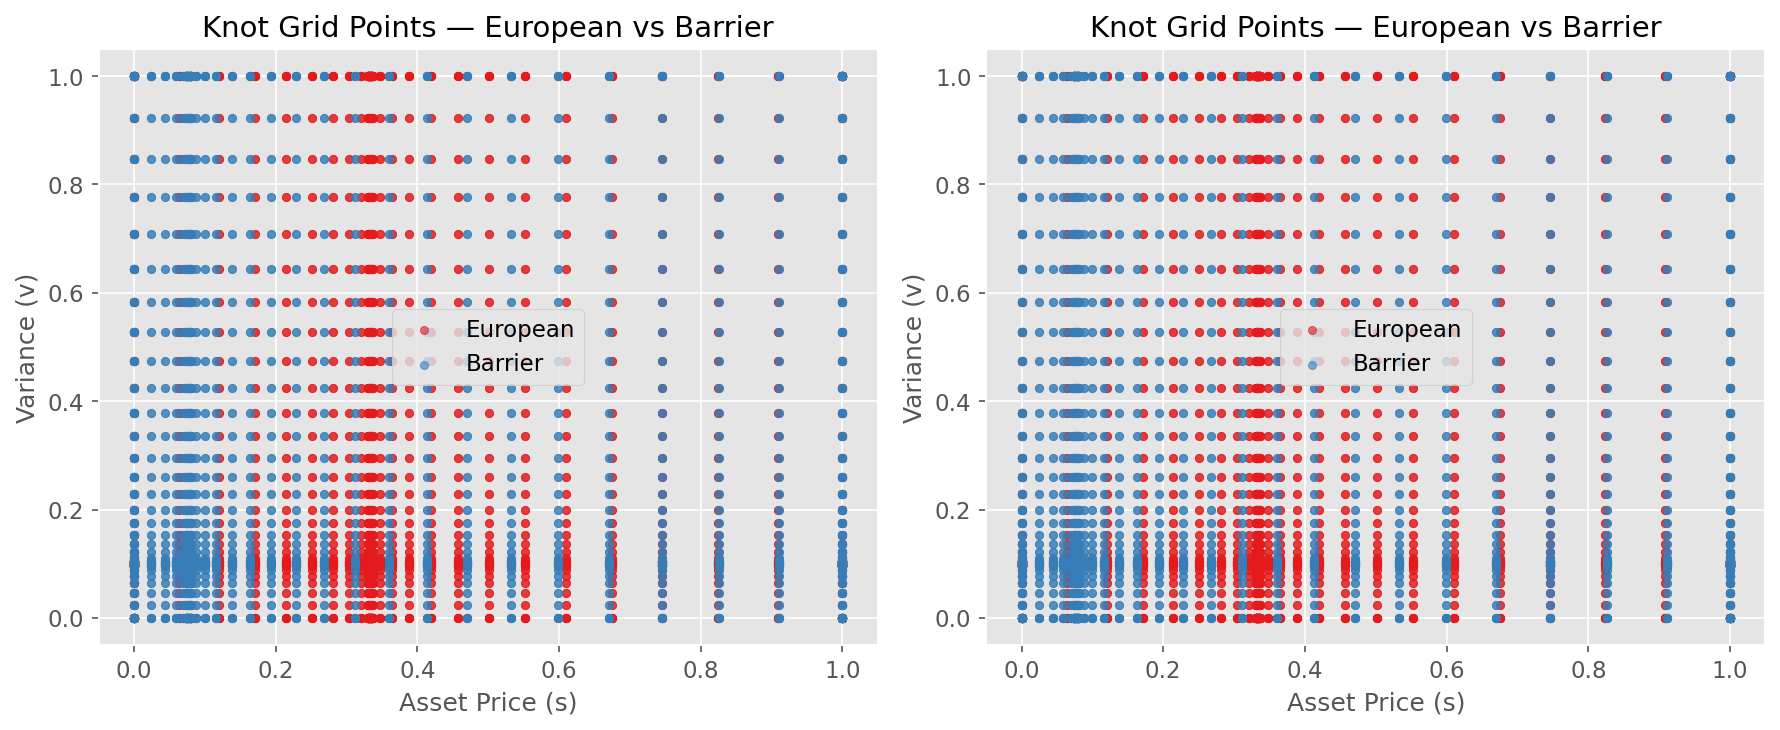

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for t, color in [("European", "#E41A1C"), ("Barrier", "#377EB8")]:
    sub = grid_df.filter(pl.col("type") == t)
    ax1.scatter(sub["s"], sub["v"], alpha=0.6, s=15, color=color, label=t)
    ax2.scatter(sub["s"], sub["v"], alpha=0.6, s=15, color=color, label=t)

ax1.set_xlabel("Asset Price (s)")
ax1.set_ylabel("Variance (v)")
ax1.set_title("Knot Grid Points — European vs Barrier")
ax1.legend()
ax2.set_xlabel("Asset Price (s)")
ax2.set_ylabel("Variance (v)")
ax2.set_title("Knot Grid Points — European vs Barrier")
ax2.legend()
fig.tight_layout()
plt.show()

---
# 4. Basis Functions

The FPE is discretized using tensor-product B-spline basis functions $B_i(s) \otimes B_j(v)$.

Boundary conditions:
- **Dirichlet** at $s=0$: absorbing boundary (price cannot go negative)
- **Neumann** at $v=0$: reflecting boundary (variance stays non-negative)

The 1D basis matrices (`Bs`, `Bv`) evaluate each basis function at the quadrature nodes. The 2D basis matrix is the Kronecker product $\text{kron}(B_s, B_v)$.

In [7]:
basis = pricer_eu.basis_1d
gp = pricer_eu.grid_points

s_grid = gp.s
v_grid = gp.v

step = 1
n_bs = basis.Bs.shape[1]
n_bv = basis.Bv.shape[1]

df_bs = pl.DataFrame([{"s": s_grid[j], "value": basis.Bs[:, i].toarray().flatten()[j], "basis": f"Bs{i}"}
    for i in range(0, n_bs, step) for j in range(len(s_grid))])

df_bv = pl.DataFrame([{"v": v_grid[j], "value": basis.Bv[:, i].toarray().flatten()[j], "basis": f"Bv{i}"}
    for i in range(0, n_bv, step) for j in range(len(v_grid))])

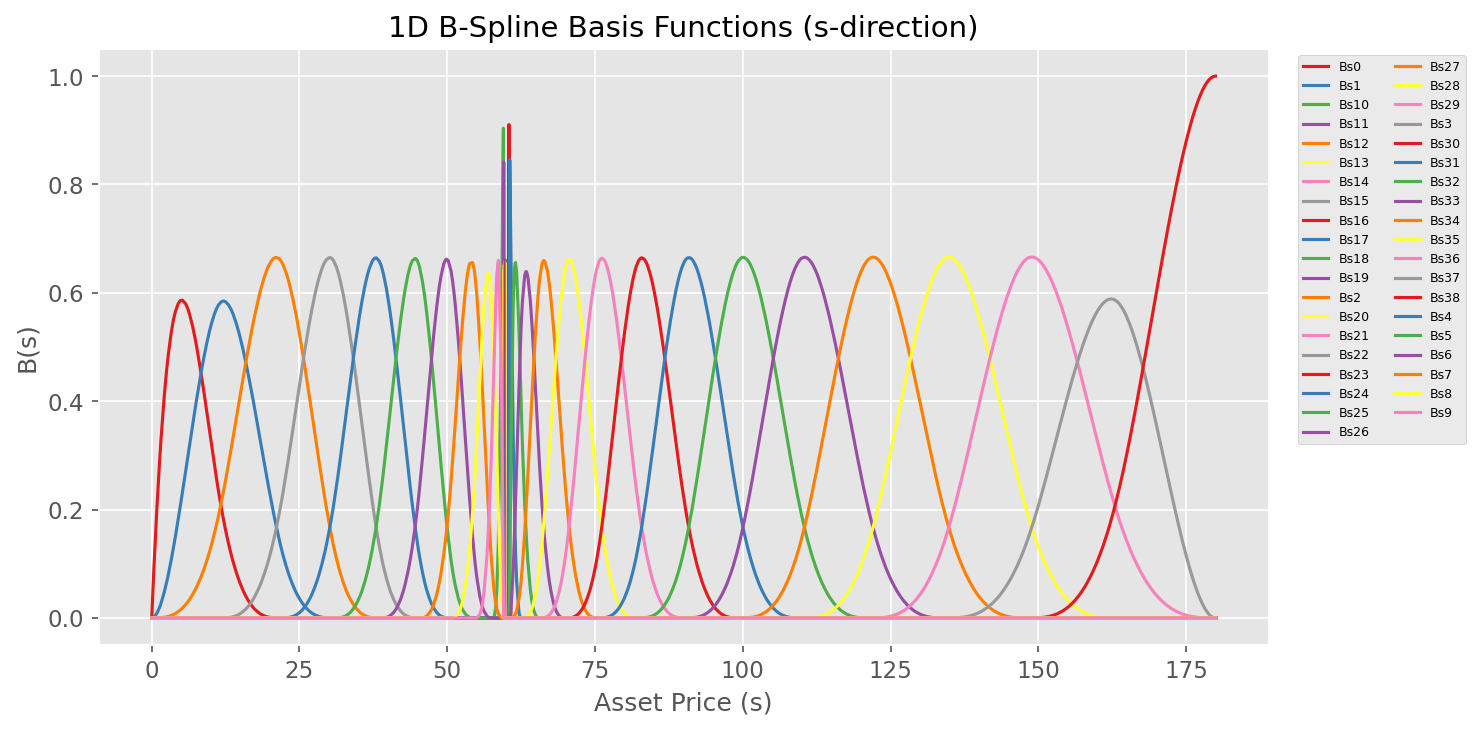

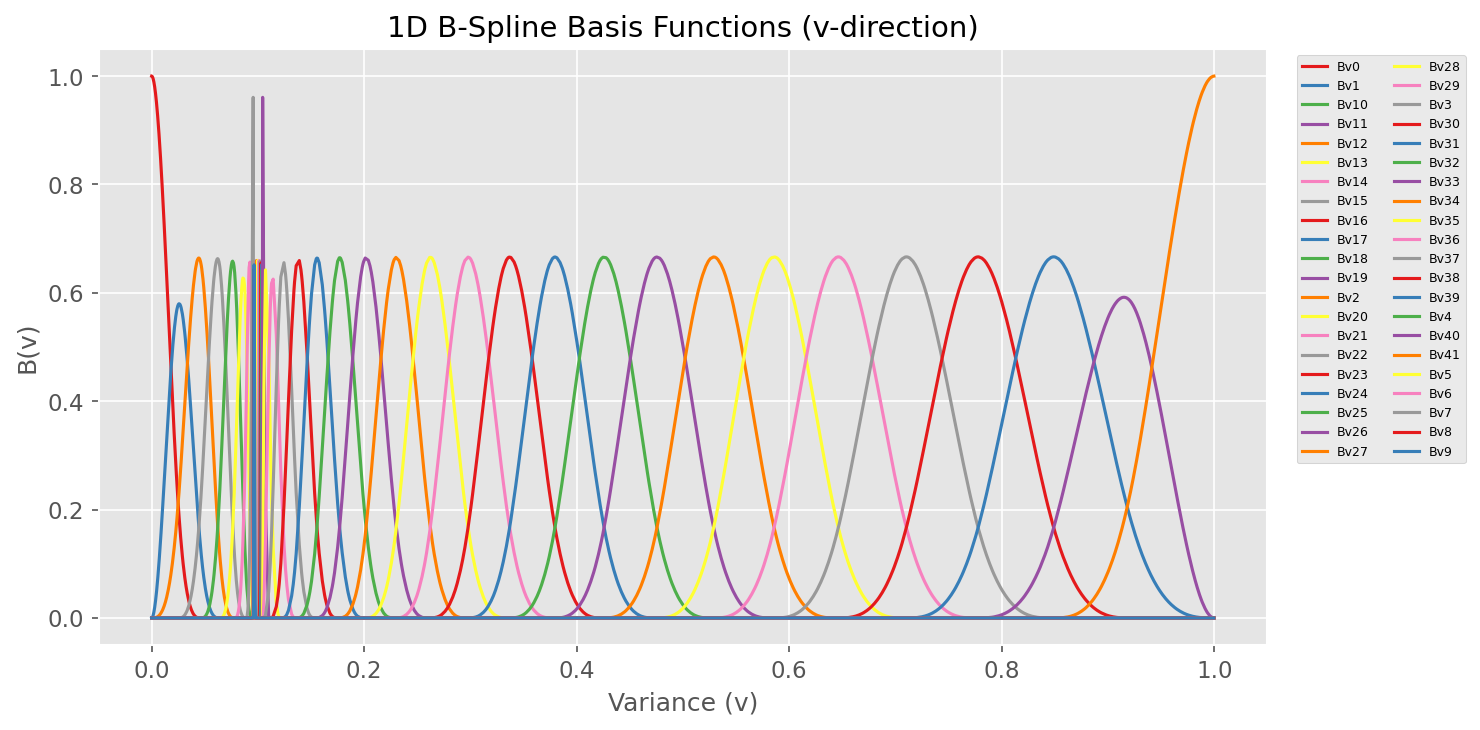

In [8]:
PALETTE = ["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", "#FFFF33", "#F781BF", "#999999"]

fig, axs = plt.subplots(figsize=(10, 5))

for idx, name in enumerate(sorted(df_bs["basis"].unique())):
    sub = df_bs.filter(pl.col("basis") == name)
    axs.plot(sub["s"], sub["value"], label=name,
             color=PALETTE[idx % len(PALETTE)], lw=1.5)
axs.set_xlabel("Asset Price (s)")
axs.set_ylabel("B(s)")
axs.set_title("1D B-Spline Basis Functions (s-direction)")
axs.legend(fontsize=6, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

fig, axv = plt.subplots(figsize=(10, 5))

for idx, name in enumerate(sorted(df_bv["basis"].unique())):
    sub = df_bv.filter(pl.col("basis") == name)
    axv.plot(sub["v"], sub["value"], label=name,
             color=PALETTE[idx % len(PALETTE)], lw=1.5)
axv.set_xlabel("Variance (v)")
axv.set_ylabel("B(v)")
axv.set_title("1D B-Spline Basis Functions (v-direction)")
axv.legend(fontsize=6, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

In [9]:
v_index = np.argmin(np.abs(gp.v - 0.3))
s_index = np.argmin(np.abs(gp.s - 120.0))

[:s_index] [:v_index] [:s_index, :v_index]

In [10]:
basis_2d = pricer_eu.basis_2d
gp = pricer_eu.grid_points
s_grid_eval = gp.s
v_grid_eval = gp.v
two_dimension = basis_2d.toarray()
basis_2d.shape

(2125100, 1638)

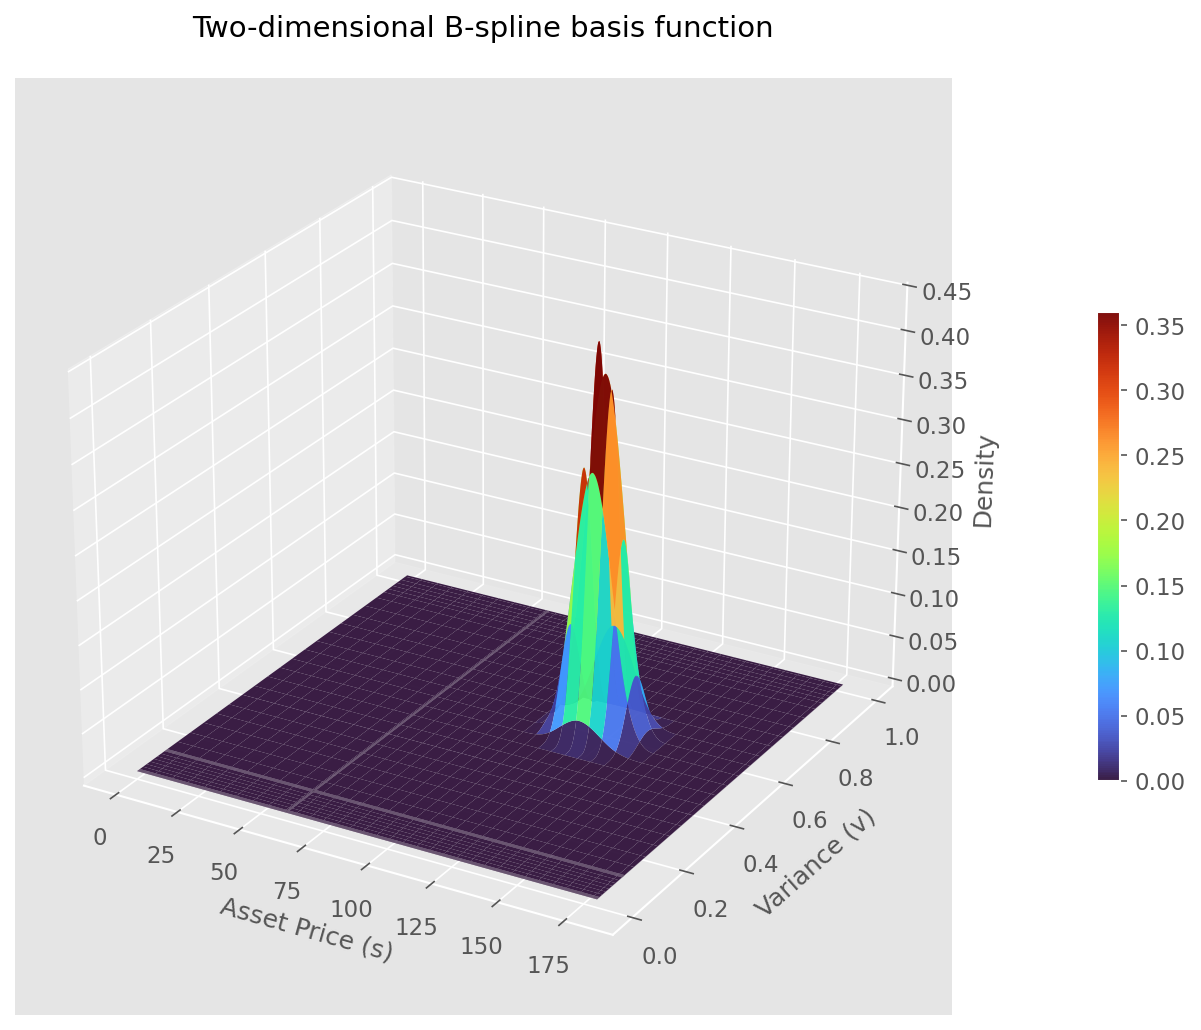

In [11]:
# Determine evaluation grid dimensions
#col_idx = basis_2d.shape[1] // 2
col_idx = 1463

Y = two_dimension[:, col_idx].reshape(len(s_grid_eval), len(v_grid_eval))

fig, ax = surface_3d_mpl(
    s_grid_eval, v_grid_eval, Y,
    title="Two-dimensional B-spline basis function",
    s_label="Asset Price (s)", v_label="Variance (v)",
)
plt.show()

---
# 5. Initial Condition

The initial condition approximates a delta function at $(S_0, V_0)$ using a narrow normal distribution. The coefficients $q_0$ are projected onto the B-spline basis, and we reconstruct the 2D approximation via $\delta(s,v) \approx B_{2D} \cdot q_0$.

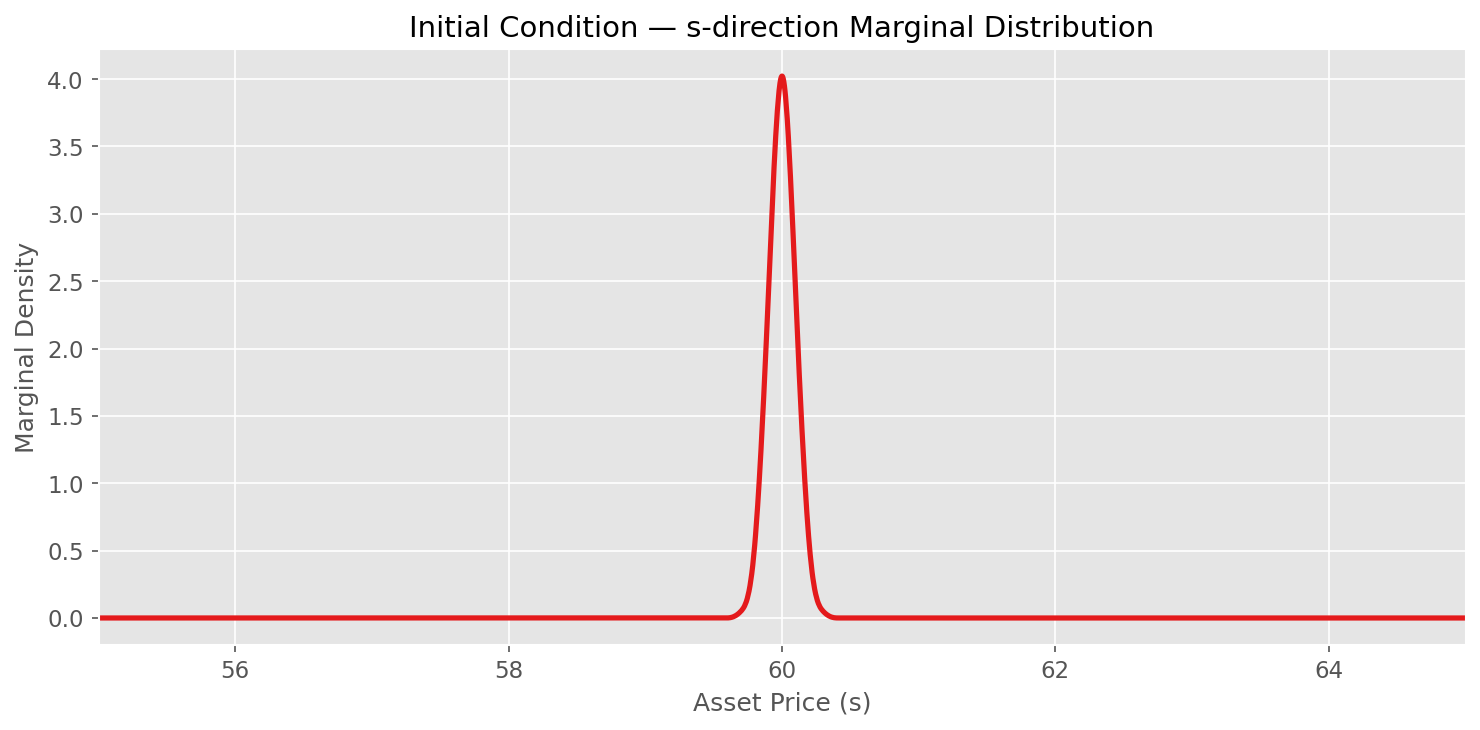

In [12]:
basis_2d = pricer_eu.basis_2d
gp = pricer_eu.grid_points
q0 = pricer_eu.initial_condition
n_s_eval = len(gp.s)
n_v_eval = len(gp.v)

delta_flat = basis_2d @ q0
delta_2d = np.array(delta_flat).reshape(n_s_eval, n_v_eval)

marginal_s = delta_2d @ gp.v_weights

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gp.s, marginal_s, lw=2.5, color=PALETTE[0])
ax.set_xlim(55, 65)
ax.set_xlabel("Asset Price (s)")
ax.set_ylabel("Marginal Density")
ax.set_title("Initial Condition — s-direction Marginal Distribution")
fig.tight_layout()
plt.show()

---
# 6. Solve & Probability Density Function

The ODE system $\mathbf{M}\dot{\mathbf{q}} + \mathbf{K}\mathbf{q} = 0$ is solved with Radau IIA, yielding the time evolution of coefficients $q(t)$. The terminal PDF at $t=T$ is reconstructed from the final coefficients.

We compare the European and barrier PDFs — the barrier PDF is zeroed out below the barrier level $s = 50$.

In [13]:
pdf_eu = pricer_eu.pdf
pdf_bar = pricer_bar.pdf
gp_eu = pricer_eu.grid_points
gp_bar = pricer_bar.grid_points

print(f"European PDF shape: {pdf_eu.shape}")
print(f"Barrier PDF shape: {pdf_bar.shape}")

European PDF shape: (1345, 1580)
Barrier PDF shape: (1345, 1580)


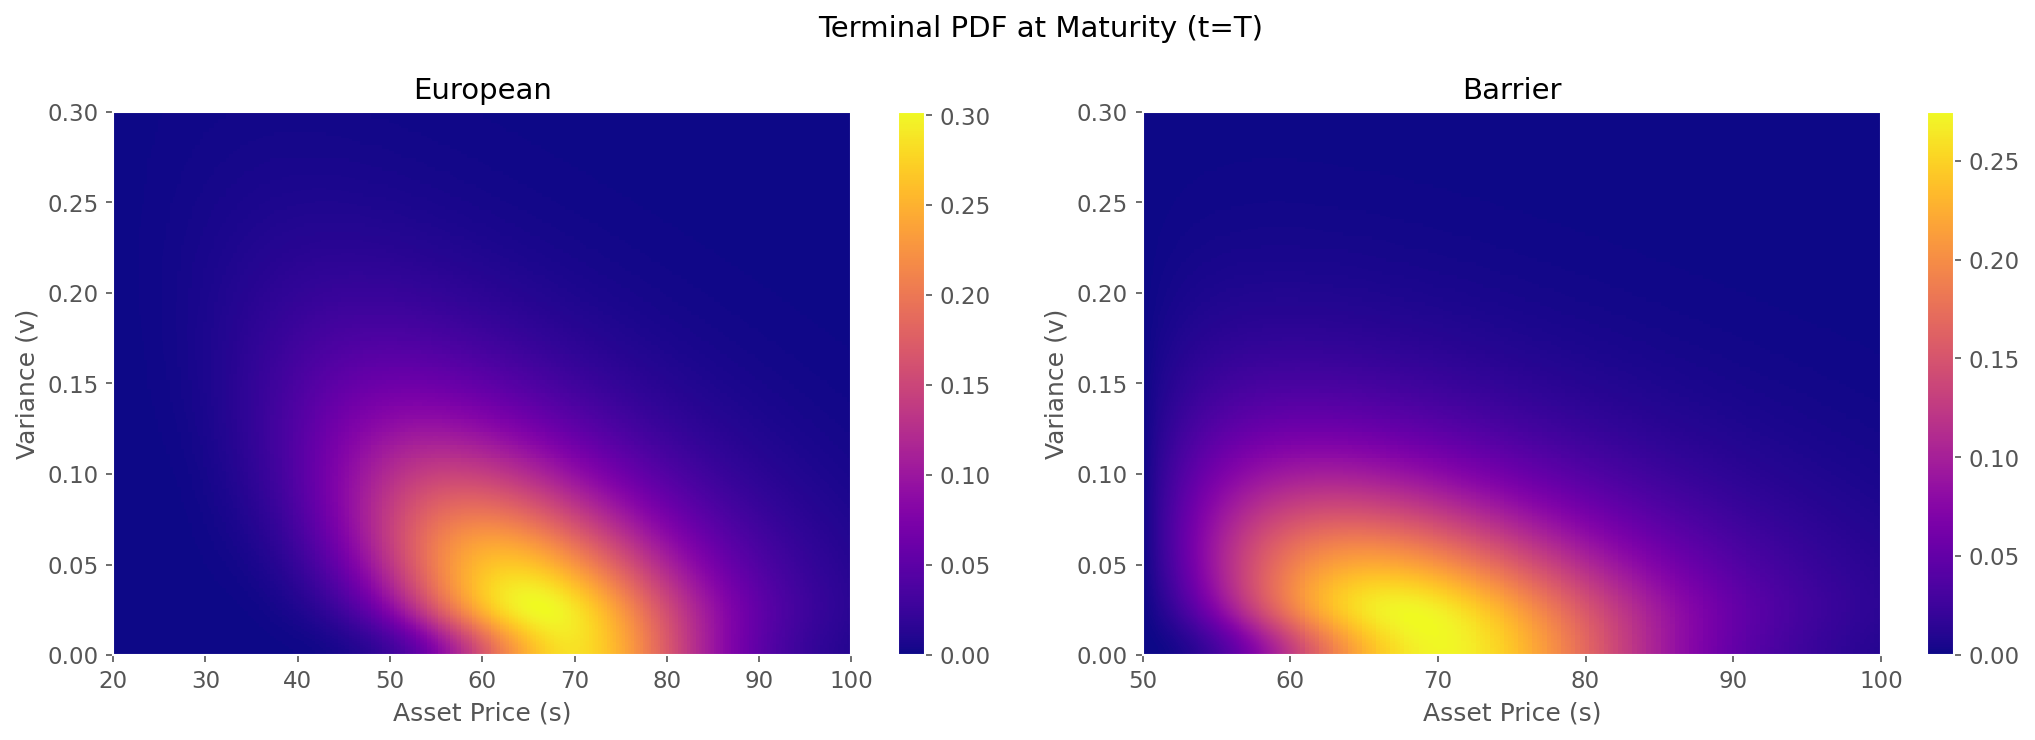

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1 = ax1.pcolormesh(gp_eu.s, gp_eu.v, pdf_eu.T, shading="auto", cmap="plasma")
ax1.set_xlabel("Asset Price (s)")
ax1.set_ylabel("Variance (v)")
ax1.set_title("European")
ax1.set_xlim(20, 100)
ax1.set_ylim(0.0, 0.3)
fig.colorbar(im1, ax=ax1)

im2 = ax2.pcolormesh(gp_bar.s, gp_bar.v, pdf_bar.T, shading="auto", cmap="plasma")
ax2.set_xlabel("Asset Price (s)")
ax2.set_ylabel("Variance (v)")
ax2.set_title("Barrier")
ax2.set_xlim(50, 100)
ax2.set_ylim(0.0, 0.3)
fig.colorbar(im2, ax=ax2)

fig.suptitle("Terminal PDF at Maturity (t=T)", fontsize=14)
fig.tight_layout()
plt.show()

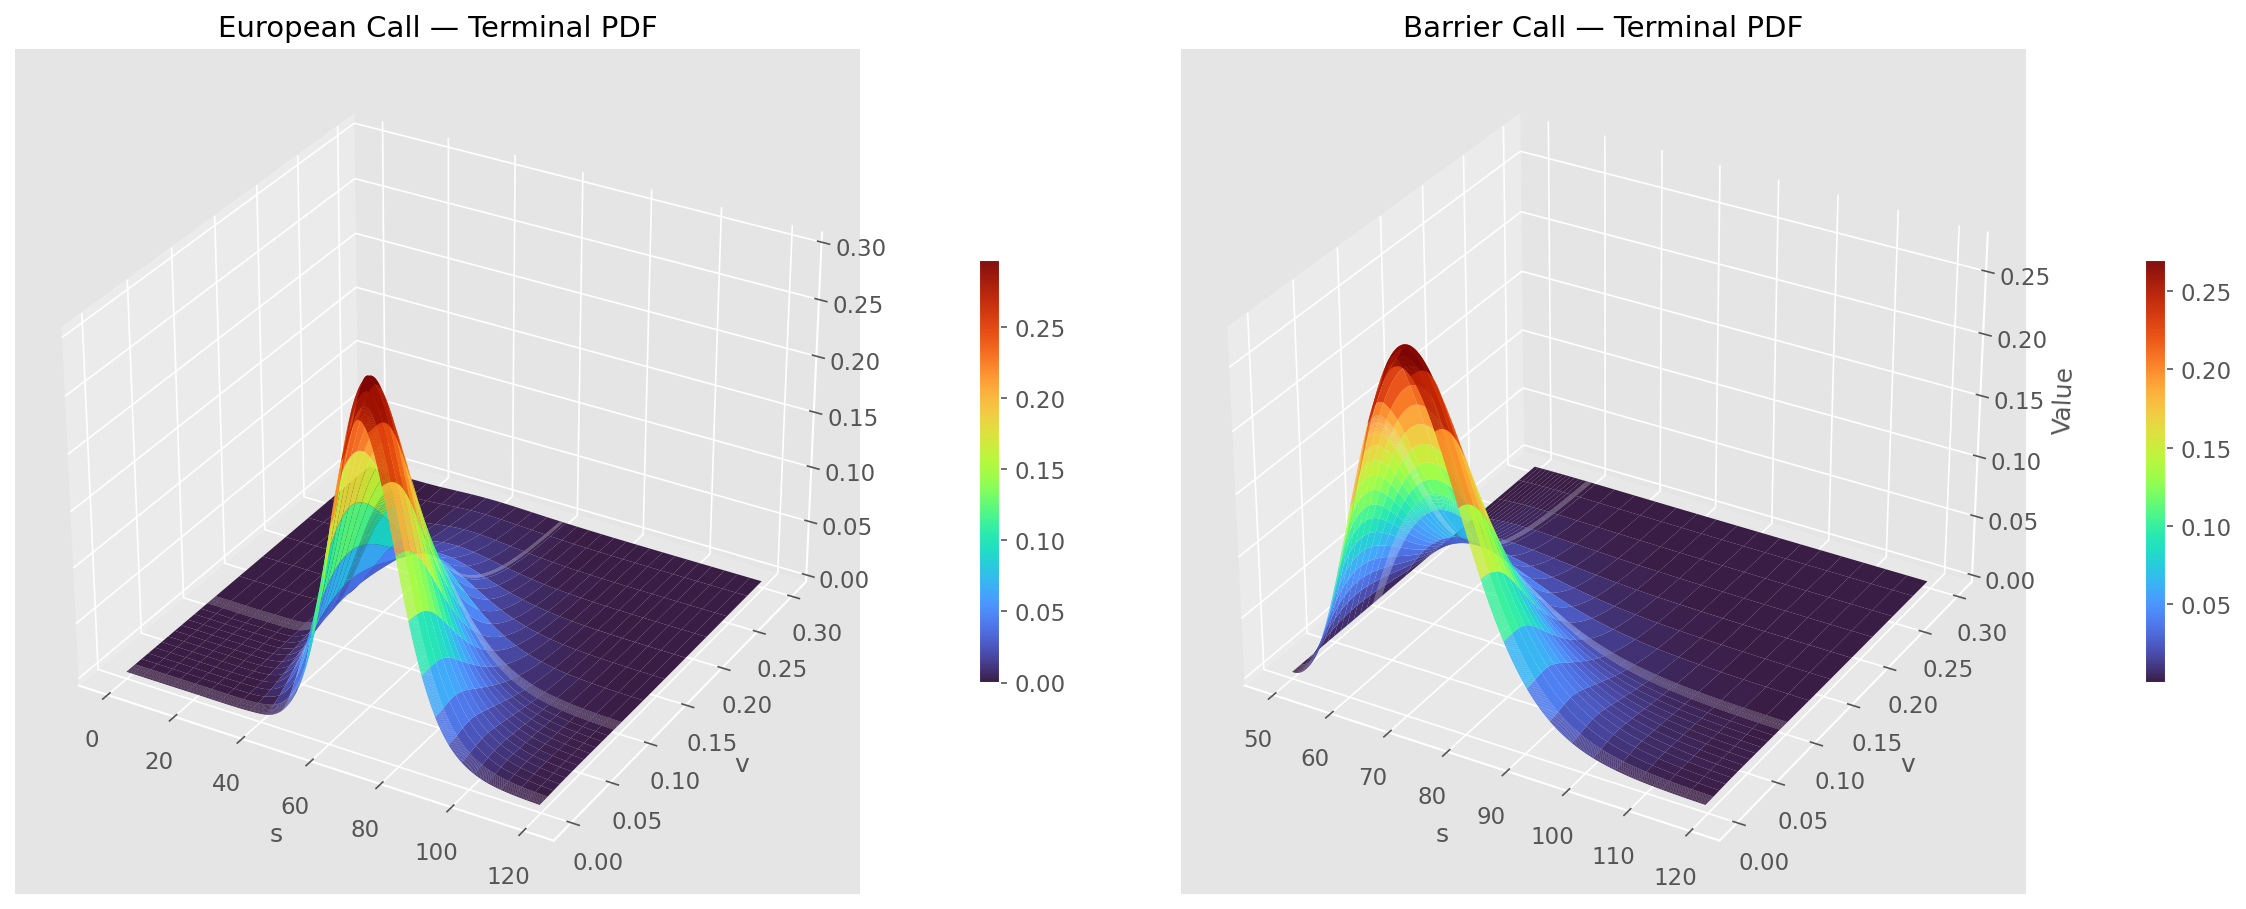

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={"projection": "3d"})

S_eu, V_eu = np.meshgrid(gp_eu.s[:s_index], gp_eu.v[:v_index], indexing="ij")
surf1 = ax1.plot_surface(S_eu, V_eu, pdf_eu[:s_index, :v_index], cmap="turbo", linewidth=0, antialiased=True, alpha=0.95)
ax1.set_xlabel("s")
ax1.set_ylabel("v")
ax1.set_title("European Call — Terminal PDF")

S_bar, V_bar = np.meshgrid(gp_bar.s[:s_index], gp_bar.v[:v_index], indexing="ij")
surf2 = ax2.plot_surface(S_bar, V_bar, pdf_bar[:s_index, :v_index], cmap="turbo", linewidth=0, antialiased=True, alpha=0.95)
ax2.set_xlabel("s")
ax2.set_ylabel("v")
ax2.set_zlabel("Value")
ax2.set_title("Barrier Call — Terminal PDF")

fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=20, pad=0.1)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=20, pad=0.1)

fig.tight_layout()
plt.show()

---
# 7. PDF Evolution Animation

Using the `solve` attribute, we retrieve the FPE solution coefficient vectors at **all adaptive time steps**, reconstruct the 2D PDF at each step, and animate the PDF evolution from $t=0$ to $t=T$.

The initial delta peak spreads due to diffusion and drifts under the Heston dynamics. For the barrier option, the absorbing boundary at $s=50$ is clearly visible.

In [ ]:
pricer = pricer_eu  # Use European pricer for full PDF evolution
basis_2d = pricer.basis_2d
gp = pricer.grid_points
s_grid = gp.s
v_grid = gp.v
n_s, n_v = len(s_grid), len(v_grid)

# Retrieve ALL time-stepped coefficient vectors
sol_coeffs = pricer.solve
n_steps = len(sol_coeffs)
print(f"Number of adaptive time steps: {n_steps}")

# Reconstruct PDF at each time step
pdfs = []
for q in sol_coeffs:
    pdf_flat = basis_2d @ q
    pdf_2d = np.array(pdf_flat).reshape(n_s, n_v)
    pdfs.append(pdf_2d)

# Create animation
T = HESTON["T"]
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
S, V = np.meshgrid(s_grid[:s_index], v_grid[:v_index], indexing="ij")


def update(frame):
    ax.clear()
    Z = pdfs[frame][:s_index, :v_index]
    surf = ax.plot_surface(S, V, Z, cmap="turbo", linewidth=0,
                           antialiased=True, alpha=0.95)
    ax.set_xlabel("Asset Price (s)")
    ax.set_ylabel("Variance (v)")
    ax.set_zlabel("Density")
    t_val = frame / max(n_steps - 1, 1) * T
    ax.set_title(f"PDF Evolution at t = {t_val:.4f}", pad=20)
    ax.view_init(elev=25, azim=-60)
    return surf,


ani = animation.FuncAnimation(fig, update, frames=n_steps, interval=100, blit=False)

writer = FFMpegWriter(fps=15, metadata={"artist": "FPE Engine", "title": "PDF Evolution"},
                      bitrate=5000)
ani.save("pdf_evolution.mp4", writer=writer, dpi=150)
plt.close()
print("Saved pdf_evolution.mp4")

### Play the animation

The video below shows the PDF evolution from $t=0$ (delta peak at $S_0=60, V_0=0.1$) to $t=T$ (terminal distribution).

In [ ]:
from IPython.display import HTML
HTML('<video controls width="800" height="600"><source src="pdf_evolution.mp4" type="video/mp4"></video>')

### Barrier PDF Evolution

In [ ]:
pricer = pricer_bar
basis_2d = pricer.basis_2d
gp = pricer.grid_points
s_grid = gp.s
v_grid = gp.v
n_s, n_v = len(s_grid), len(v_grid)

sol_coeffs = pricer.solve
n_steps = len(sol_coeffs)
print(f"Barrier - Number of adaptive time steps: {n_steps}")

pdfs = []
for q in sol_coeffs:
    pdf_flat = basis_2d @ q
    pdf_2d = np.array(pdf_flat).reshape(n_s, n_v)
    pdfs.append(pdf_2d)

T = HESTON["T"]
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
S, V = np.meshgrid(s_grid[:s_index], v_grid[:v_index], indexing="ij")


def update(frame):
    ax.clear()
    Z = pdfs[frame][:s_index, :v_index]
    surf = ax.plot_surface(S, V, Z, cmap="turbo", linewidth=0,
                           antialiased=True, alpha=0.95)
    ax.set_xlabel("Asset Price (s)")
    ax.set_ylabel("Variance (v)")
    ax.set_zlabel("Density")
    t_val = frame / max(n_steps - 1, 1) * T
    ax.set_title(f"Barrier PDF Evolution at t = {t_val:.4f}", pad=20)
    ax.view_init(elev=25, azim=-60)
    return surf,


ani = animation.FuncAnimation(fig, update, frames=n_steps, interval=100, blit=False)
writer = FFMpegWriter(fps=15, metadata={"artist": "FPE Engine", "title": "Barrier PDF Evolution"},
                      bitrate=5000)
ani.save("pdf_evolution_barrier.mp4", writer=writer, dpi=150)
plt.close()
print("Saved pdf_evolution_barrier.mp4")

In [ ]:
HTML('<video controls width="800" height="600"><source src="pdf_evolution_barrier.mp4" type="video/mp4"></video>')

---
# 8. Marginal Distributions

We integrate over one dimension to get the marginal PDF of asset price $p_S(s) = \int p(s,v)\,dv$ and marginal PDF of variance $p_V(v) = \int p(s,v)\,ds$.

In [20]:
s_weights = pricer_eu.grid_points.s_weights
v_weights = pricer_eu.grid_points.v_weights

df_marg_s = pl.concat([
    pl.DataFrame({"s": gp_eu.s, "density": pdf_eu @ v_weights, "type": "European"}),
    pl.DataFrame({"s": gp_bar.s, "density": pdf_bar @ v_weights, "type": "Barrier"}),
])

df_marg_v = pl.concat([
    pl.DataFrame({"v": gp_eu.v, "density": pdf_eu.T @ s_weights, "type": "European"}),
    pl.DataFrame({"v": gp_bar.v, "density": pdf_bar.T @ s_weights, "type": "Barrier"}),
])

print("Marginal distributions computed.")

Marginal distributions computed.


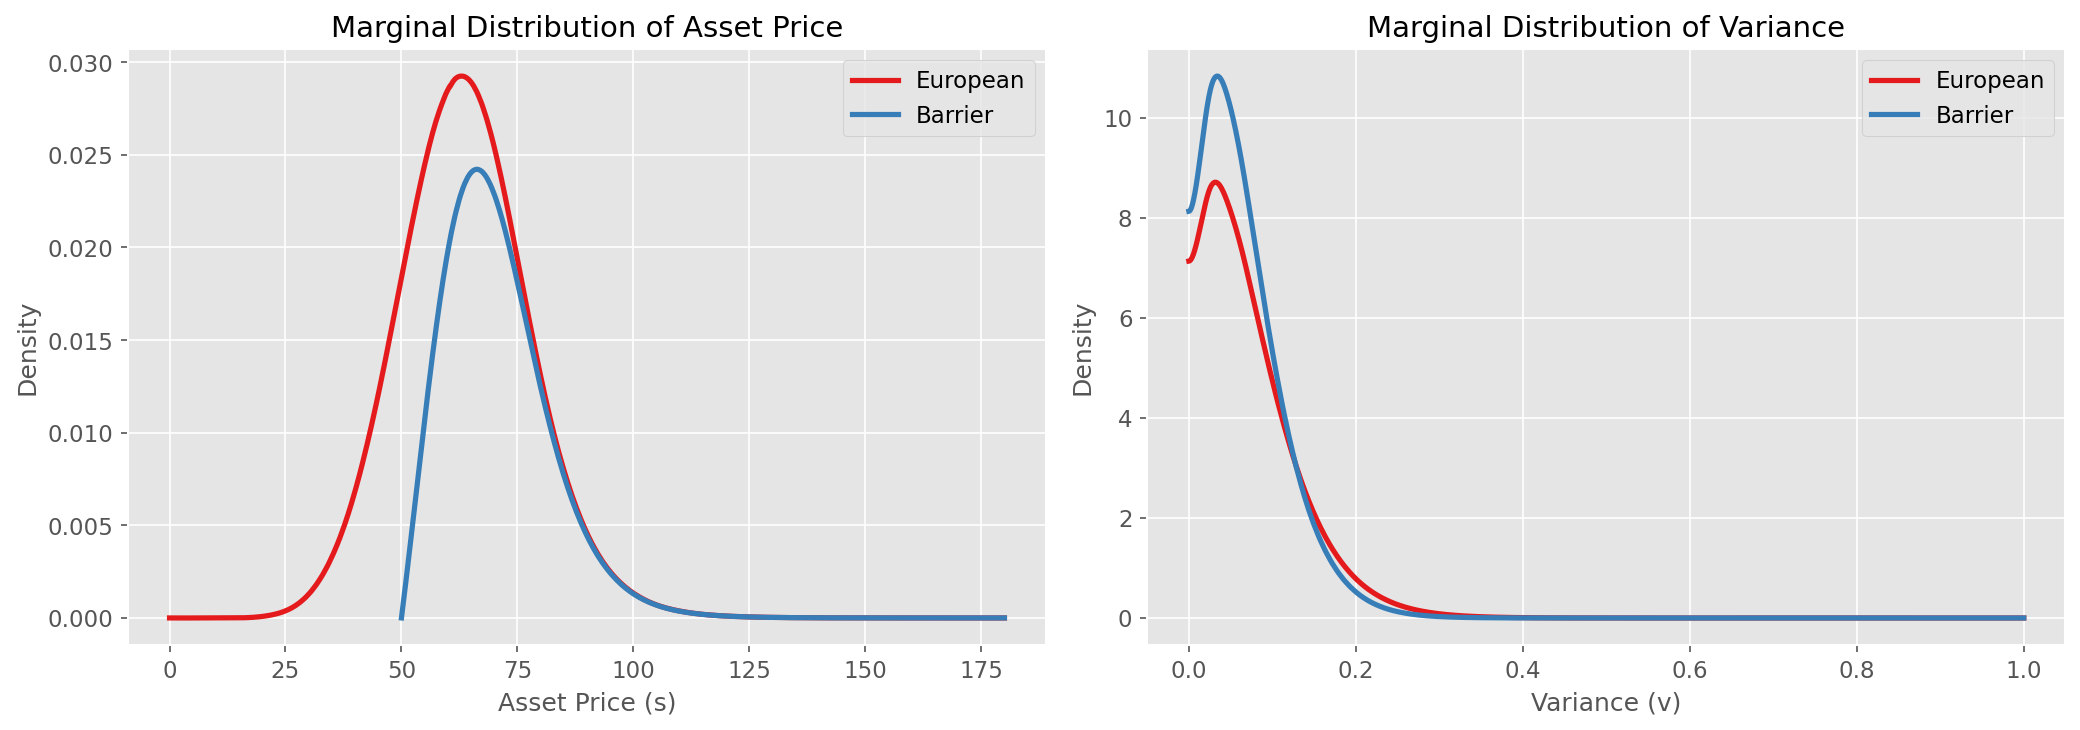

In [21]:
fig, (axs, axv) = plt.subplots(1, 2, figsize=(14, 5))

for t, color in [("European", "#E41A1C"), ("Barrier", "#377EB8")]:
    sub = df_marg_s.filter(pl.col("type") == t)
    axs.plot(sub["s"], sub["density"], label=t, color=color, lw=2.5)
axs.set_xlabel("Asset Price (s)")
axs.set_ylabel("Density")
axs.set_title("Marginal Distribution of Asset Price")
axs.legend()

for t, color in [("European", "#E41A1C"), ("Barrier", "#377EB8")]:
    sub = df_marg_v.filter(pl.col("type") == t)
    axv.plot(sub["v"], sub["density"], label=t, color=color, lw=2.5)
axv.set_xlabel("Variance (v)")
axv.set_ylabel("Density")
axv.set_title("Marginal Distribution of Variance")
axv.legend()

fig.tight_layout()
plt.show()

---
# 9. Barrier Option Pricing vs Monte Carlo

 integrates the call payoff $\max(S - K, 0)$ against the terminal PDF.
The FPE solver yields prices at =0$ (present value under risk-neutral measure).
Monte Carlo reference values are at =T$ (undiscounted), so we convert:

57015	ext{FPE}_T = 	ext{FPE}_0 \cdot e^{rT}57015

and compare against $	ext{MC}_{	ext{bar}}$ at maturity.


In [22]:
STRIKES = [65, 70, 75, 80, 85, 90, 95, 100]
r = HESTON["r"]
T = HESTON["T"]
disc = np.exp(r * T)  # e^(rT) conversion factor to bring FPE to T

# T-time Monte Carlo barrier prices (undiscounted, at maturity)
MC_BAR_T = [4.716, 2.939, 1.729, 0.973, 0.531, 0.285, 0.152, 0.0805]

# FPE barrier prices at t=0 (present value)
fpe_bar_0 = np.array(pricer_bar.payoff_price(STRIKES))

# Convert FPE to T-time for comparison
fpe_bar_T = fpe_bar_0 * disc

df_price_bar = pl.DataFrame({
    "K": STRIKES,
    "FPE_T": fpe_bar_T,
    "MC_bar_T": MC_BAR_T,
}).with_columns(
    rel_error_pct=pl.when(pl.col("MC_bar_T") != 0)
        .then((pl.col("FPE_T") - pl.col("MC_bar_T")).abs() / pl.col("MC_bar_T") * 100)
        .otherwise(0.0)
)

print(f"Discount factor e^(rT) = {disc:.6f}")
display(df_price_bar)

Discount factor e^(rT) = 1.061837


K,FPE_T,MC_bar_T,rel_error_pct
i64,f64,f64,f64
65,4.713256,4.716,0.058176
70,2.94113,2.939,0.072481
75,1.733301,1.729,0.248731
80,0.976814,0.973,0.392033
85,0.533807,0.531,0.528626
90,0.28632,0.285,0.46311
95,0.152251,0.152,0.165223
100,0.080859,0.0805,0.446129


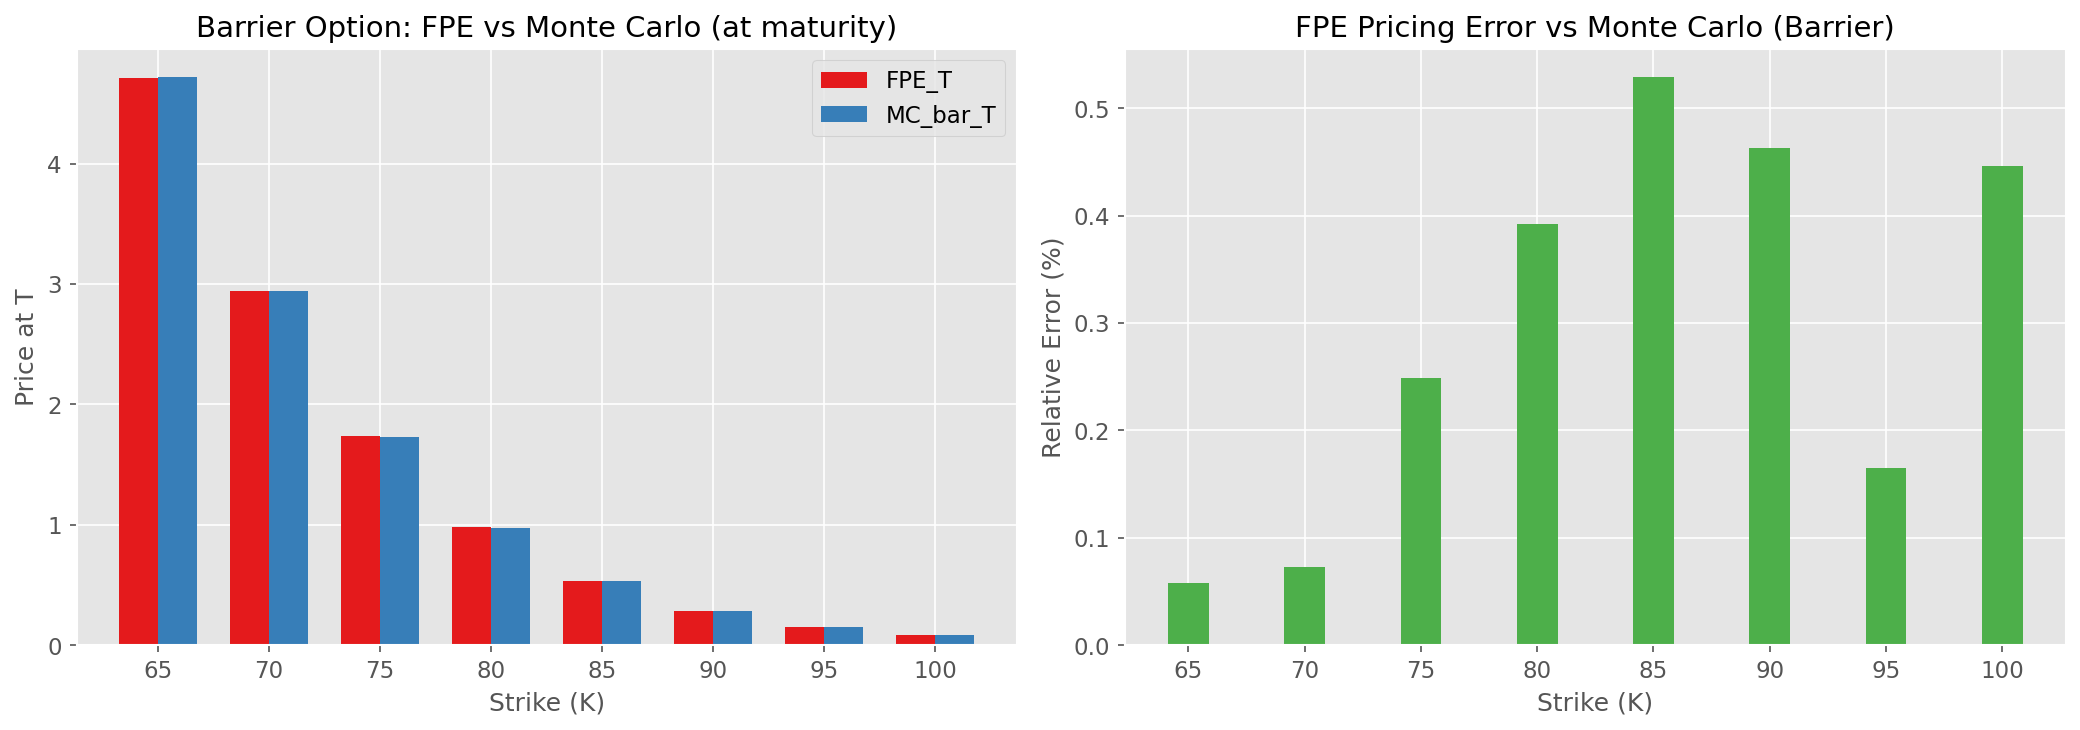

In [23]:
colors = {"FPE_T": "#E41A1C", "MC_bar_T": "#377EB8"}

fig, (ax_price, ax_err) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(STRIKES))
w = 0.35
ax_price.bar(x - w/2, df_price_bar["FPE_T"], w, label="FPE_T", color=colors["FPE_T"])
ax_price.bar(x + w/2, df_price_bar["MC_bar_T"], w, label="MC_bar_T", color=colors["MC_bar_T"])
ax_price.set_xlabel("Strike (K)")
ax_price.set_ylabel("Price at T")
ax_price.set_title("Barrier Option: FPE vs Monte Carlo (at maturity)")
ax_price.set_xticks(x)
ax_price.set_xticklabels(STRIKES)
ax_price.legend()

ax_err.bar(x, df_price_bar["rel_error_pct"], w, color="#4DAF4A")
ax_err.set_xlabel("Strike (K)")
ax_err.set_ylabel("Relative Error (%)")
ax_err.set_title("FPE Pricing Error vs Monte Carlo (Barrier)")
ax_err.set_xticks(x)
ax_err.set_xticklabels(STRIKES)

fig.tight_layout()
plt.show()

---
# 10. Convergence Study — Quadrature Resolution

The FPE engine uses Gauss-Legendre quadrature on each B-spline element
to assemble the mass matrix $\mathbf{M}$ and stifness matrix $\mathbf{K}$.
The parameter `num_insert` controls the number of quadrature points per element.

We test convergence by increasing the number of quadrature points
while holding the B-spline grid fixed at $n_s = n_v = 38$:

$$\text{num\_insert} \in \{10, 25, 50, 75, 100, 150, 200, 251\}$$

Prices are converted to $t=T$ using $e^{rT}$ for comparison with Monte Carlo.


In [24]:
NUM_INSERT = [10, 25, 50, 75, 100, 150, 200, 251]
K_CONV = 100.0
MC_REF_BAR_T = 0.0805  # T-time MC reference at K=100

rows = []
for ni in NUM_INSERT:
    p = Compute(**HESTON, n_s=38, n_v=38,
                option_type="down_and_out_call", barrier=50.0,
                num_insert=ni)
    r = p.payoff_price(K_CONV)
    fpe_T = r[0] * disc  # convert to T-time
    rows.append({"num_insert": ni, "price_T": fpe_T})

df_conv = pl.DataFrame(rows)
display(df_conv.with_columns(
    rel_error_pct=(pl.col("price_T") - MC_REF_BAR_T).abs()
                 / MC_REF_BAR_T * 100
))

num_insert,price_T,rel_error_pct
i64,f64,f64
10,1.4093e-27,100.0
25,1.3163e-27,100.0
50,0.077259,4.02617
75,0.079342,1.438194
100,0.080683,0.227723
150,0.080849,0.433095
200,0.080834,0.414395
251,0.080859,0.446129


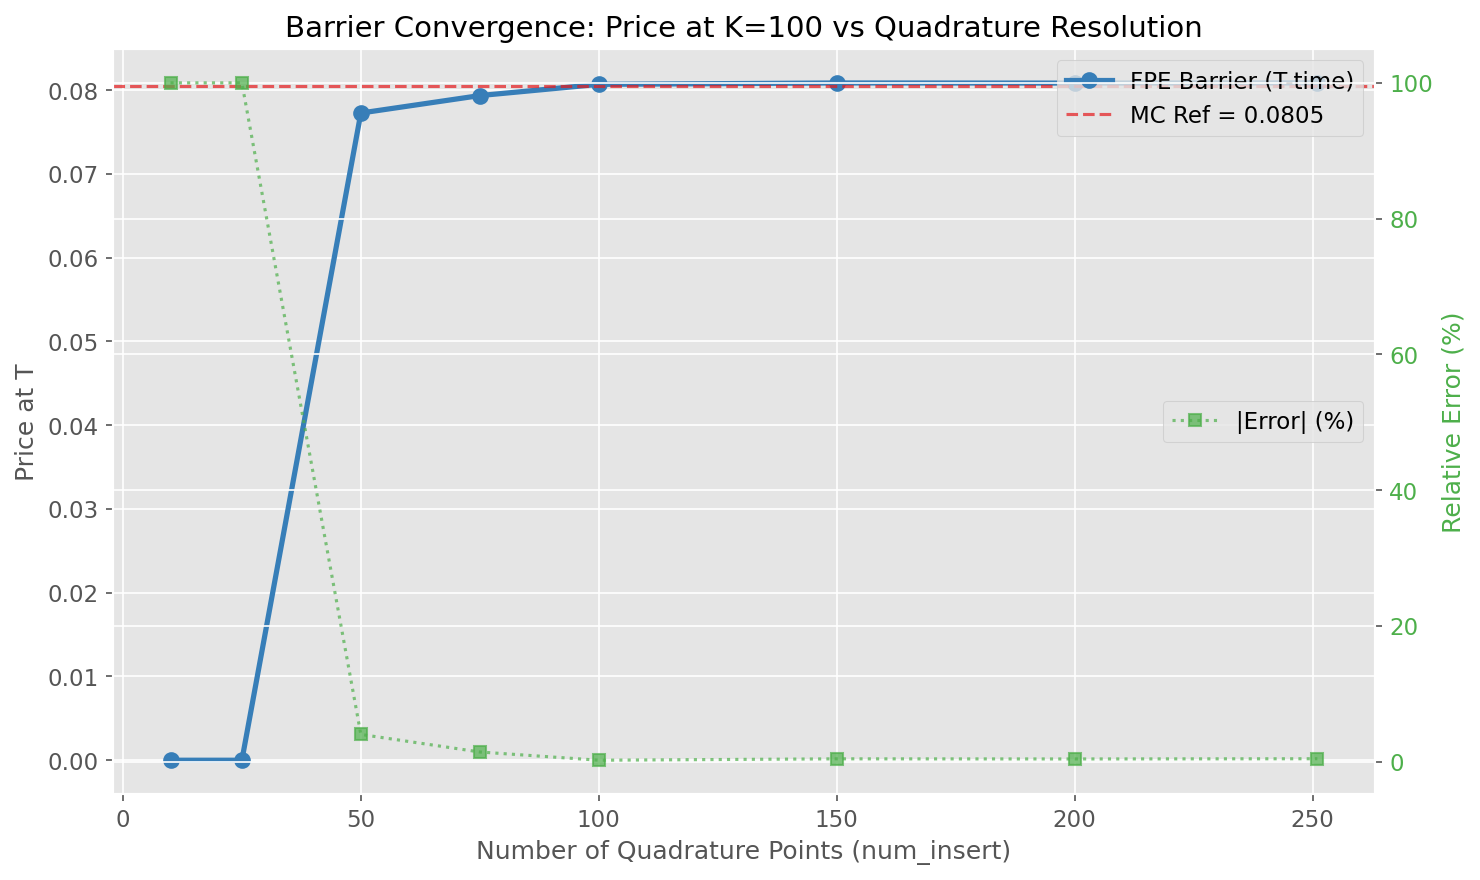

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Price convergence on left axis
ax1.plot(df_conv["num_insert"], df_conv["price_T"],
         marker="o", lw=2.5, color="#377EB8", markersize=7,
         label="FPE Barrier (T-time)")
ax1.axhline(y=MC_REF_BAR_T, color="#E41A1C", linestyle="--",
            alpha=0.7, label=f"MC Ref = {MC_REF_BAR_T}")
ax1.set_xlabel("Number of Quadrature Points (num_insert)")
ax1.set_ylabel("Price at T")
ax1.set_title("Barrier Convergence: Price at K=100 vs Quadrature Resolution")
ax1.legend(loc="upper right")

# Error convergence on right axis
errors = (df_conv["price_T"] - MC_REF_BAR_T).abs() / MC_REF_BAR_T * 100
ax2 = ax1.twinx()
ax2.plot(df_conv["num_insert"], errors, marker="s", lw=1.5,
         linestyle=":", color="#4DAF4A", markersize=6, alpha=0.7,
         label="|Error| (%)")
ax2.set_ylabel("Relative Error (%)", color="#4DAF4A")
ax2.tick_params(axis="y", labelcolor="#4DAF4A")
ax2.legend(loc="center right")

fig.tight_layout()
plt.show()

---
# 11. Convergence Study — B‑Spline Grid Resolution

The number of B‑spline knots in each dimension ($n_s$, $n_v$) controls the spatial resolution of the finite‑element approximation.
More knots capture finer features of the probability density but increase the ODE system size and solve time.

Here we vary $n_s = n_v$ from the base `38` both downward and upward, keeping `num_insert=251` fixed.


In [26]:
KNOT_SIZES = [22, 28, 34, 38, 42, 48]
K_CONV = 100.0
NI_FIXED = 251

rows_knot = []
for n in KNOT_SIZES:
    p = Compute(**HESTON, n_s=n, n_v=n,
                option_type="down_and_out_call", barrier=50.0,
                num_insert=NI_FIXED)
    r = p.payoff_price(K_CONV)
    fpe_T = r[0] * disc  # convert to T-time
    rows_knot.append({"n_knot": n, "price_T": fpe_T})

df_knot = pl.DataFrame(rows_knot)

display(df_knot.with_columns(
    rel_error_pct=(pl.col("price_T") - MC_REF_BAR_T).abs()
                 / MC_REF_BAR_T * 100
))

n_knot,price_T,rel_error_pct
i64,f64,f64
22,0.084058,4.420148
28,0.080947,0.555016
34,0.080822,0.399382
38,0.080859,0.446129
42,0.080861,0.448466
48,0.08083,0.409889


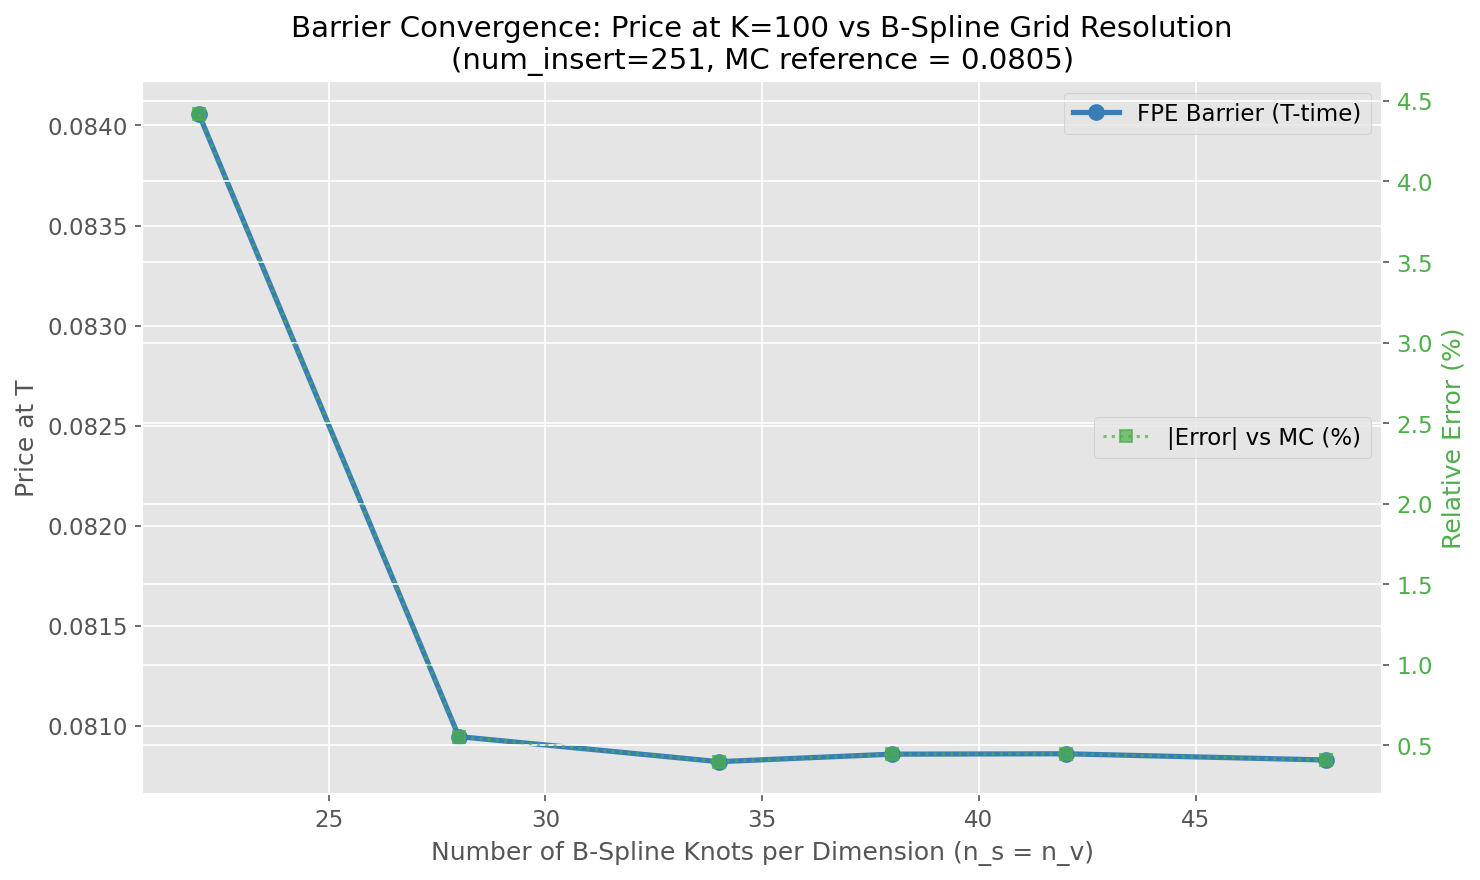

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(df_knot["n_knot"], df_knot["price_T"],
         marker="o", lw=2.5, color="#377EB8", markersize=7,
         label="FPE Barrier (T-time)")
ax1.set_xlabel("Number of B‑Spline Knots per Dimension (n_s = n_v)")
ax1.set_ylabel("Price at T")
ax1.set_title(
    "Barrier Convergence: Price at K=100 vs B‑Spline Grid Resolution\n"
    f"(num_insert={NI_FIXED}, MC reference = {MC_REF_BAR_T})"
)
ax1.legend(loc="upper right")

errors = (df_knot["price_T"] - MC_REF_BAR_T).abs() / MC_REF_BAR_T * 100
ax2 = ax1.twinx()
ax2.plot(df_knot["n_knot"], errors, marker="s", lw=1.5,
         linestyle=":", color="#4DAF4A", markersize=6, alpha=0.7,
         label="|Error| vs MC (%)")
ax2.set_ylabel("Relative Error (%)", color="#4DAF4A")
ax2.tick_params(axis="y", labelcolor="#4DAF4A")
ax2.legend(loc="center right")

fig.tight_layout()
plt.show()